In [1]:
import numpy as np

In [2]:
%env JAX_ENABLE_X64=True

env: JAX_ENABLE_X64=True


In [3]:
from lenstronomy.LensModel.lens_model import LensModel
import lensinggw.constants.constants as const
from lensinggw.utils.utils import TimeDelay, magnifications, getMinMaxSaddle

In [4]:
import sys
import os
path = os.getcwd()
dir = '/home/manchun.yeung/microlensing/wolensing/wolensing'
sys.path.append(dir)

In [5]:
from plot.plot import plot_contour
import amplification_factor.amplification_factor as af
from lensmodels.potential import potential

The macroimage where the microlens is placed around.

In [6]:
type2 = False

In [7]:
ym = 0.8
angle = np.radians(float(0))

Importing constants

In [8]:
G = const.G  # gravitational constant [m^3 kg^-1 s^-2]
c = const.c  # speed of light [m/s]
M_sun = const.M_sun  # Solar mass [Kg]

In [9]:
y0, y1 = 0.5, 0 # source position
l0, l1 = 0., 0 # lens position

zS = 1.0 # source redshift
zL = 0.5 # lens redshift

In [10]:
mL1 = 1e10
mL2 = 20
mtot = mL1 + mL2

# convert to radians
from lensinggw.utils.utils import param_processing
thetaE1 = param_processing(zL, zS, mL1)
thetaE2 = param_processing(zL, zS, mL2)
thetaE = param_processing(zL, zS, mtot)

In [11]:
thetaE

8.052888069635299e-07

In [12]:
Mpc=3.085677581491367e+22
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=69.7, Om0=0.306, Tcmb0=2.725)
DL       = cosmo.angular_diameter_distance(zL)
DS       = cosmo.angular_diameter_distance(zS)
DLS      = cosmo.angular_diameter_distance_z1z2(zL, zS)
D        = DLS/(DL*DS)
print(np.float64(D/Mpc))

1.097926071881248e-26


In [13]:
from utils.utils import Einstein_radius

In [14]:
Einstein_radius(zL, zS, mtot)

1.097926071881248e-26


8.052888069635299e-07

In [15]:
beta0, beta1 = y0 * thetaE, y1 * thetaE
eta10, eta11 = 0 * l0 * thetaE, 0 * l1 * thetaE
lens_model_list = ['SIS']
kwargs_sis_1 = {'center_x': eta10, 'center_y': eta11, 'theta_E': thetaE1}
kwargs_lens_list = [kwargs_sis_1]

kwargs_sis_1_scaled = {'center_x': eta10 / thetaE, 'center_y': eta11 / thetaE, 'theta_E': thetaE1 / thetaE}
kwargs_lens_list_scaled = [kwargs_sis_1_scaled]

from lensinggw.solver.images import microimages
solver_kwargs = {'SearchWindowMacro': 10 * thetaE1,
                 'SearchWindow': 5 * thetaE2,
                 'OverlapDistMacro': 1e-17,
                 'OnlyMacro': True}
MacroImg_ra, MacroImg_dec, pixel_width = microimages(source_pos_x=beta0,
                                                     source_pos_y=beta1,
                                                     lens_model_list=lens_model_list,
                                                     kwargs_lens=kwargs_lens_list,
                                                     **solver_kwargs)

Td = TimeDelay(MacroImg_ra, MacroImg_dec,
                beta0, beta1,
                zL, zS,
                lens_model_list, kwargs_lens_list)
Mus = magnifications(MacroImg_ra, MacroImg_dec, lens_model_list, kwargs_lens_list)
if type2:
    microtype = np.nonzero(Td)[0][0]
else:
    microtype = np.where(Td==0)[0][0]

masses = [60]
angle = [45]
ym = [0.8]

num_points = len(masses)
for j in range(0,num_points):
    theta_E = param_processing(zL, zS, masses[j])# lens model
    #positioning the microlenses
    eta20 = MacroImg_ra[microtype] + ym[j]*np.cos(np.radians(angle[j])) * theta_E
    eta21 = MacroImg_dec[microtype] + ym[j] * np.sin(np.radians(angle[j])) * theta_E
    lens_model_list.append('POINT_MASS')
    kwargs_lens_list.append({'center_x': eta20, 'center_y': eta21, 'theta_E': theta_E})

# mass_density = 100
# from utils.lensing import *
# radius = injection_radius(masses, mass_density) #rad
# lens_model_list, kwargs_lens_list = field_injection(zL, zS, MacroImg_ra[microtype], MacroImg_dec[microtype], masses, radius, lens_model_list, kwargs_lens_list, seed=1)
    
# Injecting microlens around desired macroimage
# eta20, eta21 = MacroImg_ra[microtype] + np.cos(angle)*ym*thetaE2, MacroImg_dec[microtype] + np.sin(angle)*ym*thetaE2
# lens_model_list = ['SIS', 'POINT_MASS']
# kwargs_sis_1 = {'center_x': eta10, 'center_y': eta11, 'theta_E': thetaE1}
# kwargs_point_mass_2 = {'center_x': eta20, 'center_y': eta21, 'theta_E': thetaE2}
# kwargs_lens_list = [kwargs_sis_1, kwargs_point_mass_2]

from lensinggw.solver.images import microimages
solver_kwargs = {'SearchWindowMacro': 10 * thetaE1,
                 'SearchWindow': 40 * thetaE2,
                 'Pixels': 5*1e3,
                 # 'ImgIndex': 1,
                 'Optimization': True,
                 'OverlapDist': 1e-18,
                 'OverlapDistMacro': 1e-17}
solver_kwargs.update({'Improvement' : 0.1})
solver_kwargs.update({'MinDist' : 10**(-7)})

Img_ra, Img_dec, MacroImg_ra, MacroImg_dec, pixel_width = microimages(source_pos_x=beta0,
                                                                      source_pos_y=beta1,
                                                                      lens_model_list=lens_model_list,
                                                                      kwargs_lens=kwargs_lens_list,
                                                                      **solver_kwargs)
# Images_dict = {'Source_ra': beta0,
#                'Source_dec': beta1,
#                'Img_ra': Img_ra,
#                'Img_dec': Img_dec,
#                'MacroImg_ra': MacroImg_ra,
#                'MacroImg_dec': MacroImg_dec,
#                'Microlens_ra': [eta20],
#                'Microlens_dec': [eta21],
#                'thetaE': thetaE}

# time delays, magnifications, Morse indices 
from lensinggw.utils.utils import TimeDelay, magnifications, getMinMaxSaddle
from lensinggw.amplification_factor.amplification_factor import geometricalOpticsMagnification
tds = TimeDelay(Img_ra, Img_dec,
               beta0, beta1,
               zL, zS,
               lens_model_list, kwargs_lens_list)
mus = magnifications(Img_ra, Img_dec, lens_model_list, kwargs_lens_list)
ns = getMinMaxSaddle(Img_ra, Img_dec, lens_model_list, kwargs_lens_list, diff = None)
print('Time delays (seconds): ', tds)
print('magnifications: ', mus)
print('Morse indices: ', ns)
    
lens_model_complete = LensModel(lens_model_list=lens_model_list)
T = lens_model_complete.fermat_potential
T0 = thetaE ** (-2) * T(Img_ra[microtype], Img_dec[microtype], kwargs_lens_list, beta0, beta1)#[0]
if not isinstance(T0, float):
    T0 = T0[0]
Tscale = 4 * (1 + zL) * mtot * M_sun * G / c ** 3
print('T0 = {}'.format(T0))
print('Tscale = {}'.format(Tscale))


---- Will perform only the macromodel analysis ----

---- Solver settings ----

The macromodel analysis will be performed with the following settings:

OnlyMacro         --> True
Scaled            --> False
SearchWindowMacro --> 8.052888061582412e-06
PixelsMacro       --> 1000
PrecisionLimit    --> 1e-20
OverlapDistMacro  --> 1e-17
NearSource        --> False
Optimization      --> False
Verbose           --> False



/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/lensinggw-1.0.0-py3.10.egg/lensinggw/solver/images.py:107: SyntaxWarning: "is not" with a literal. Did you mean "!="?
/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/lensinggw-1.0.0-py3.10.egg/lensinggw/solver/images.py:107: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/lensinggw-1.0.0-py3.10.egg/lensinggw/solver/images.py:108: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/lensinggw-1.0.0-py3.10.egg/lensinggw/solver/images.py:117: SyntaxWarning: "is not" with a literal. Did you mean "!="?
/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/lensinggw-1.0.0-py3.10.egg/lensinggw/solver/images.py:117: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packa




MACROIMAGES

ra: [-4.02644403e-07  1.20793321e-06]
dec: [-4.23516474e-22 -4.23516474e-22]


---- Solver settings ----

The macromodel analysis will be performed with the following settings:

OnlyMacro                       --> False
Scaled                          --> False
SearchWindowMacro               --> 8.052888061582412e-06
PixelsMacro                     --> 1000
OverlapDistMacro                --> 1e-17
NearSource                      --> False
Optimization                    --> True
Verbose                         --> False
OptimizationWindowMacro         --> 2
OptimizationPixelsMacro         --> 30
MinDistMacro                    --> None
ImprovementMacro                --> None
OptimizationPrecisionLimitMacro --> 1e-20




MACROIMAGES

ra: [-4.02644403e-07  1.20793321e-06]
dec: [-4.23516474e-22 -4.23516474e-22]


---- Solver settings ----

The complete model analysis will be performed with the following settings:

Scaled                          --> False
OnlyMacro     

In [16]:
Img_ra = np.delete(Img_ra, [0])
Img_dec = np.delete(Img_dec, [0])

In [17]:
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LensModel.lens_model import LensModel
lensmodel = LensModel(lens_model_list=lens_model_list)
solver = LensEquationSolver(
    lensModel = lensmodel
)
Img_ra, Img_dec = solver.image_position_stochastic(
    source_x = beta0,
    source_y = beta1,
    kwargs_lens = kwargs_lens_list,
    # min_distance = 1e-13,
    # solver='lenstronomy'
    search_window = 20*thetaE2,
    # verbose=True,
    precision_limit=10**(-17),
    x_center = MacroImg_ra[microtype],
    y_center= MacroImg_dec[microtype]
)

In [18]:
Img_ra, Img_dec

(array([1.20792235e-06, 1.20801475e-06]),
 array([-8.47327879e-11,  4.35150951e-11]))

In [19]:
lens_model_complete = LensModel(lens_model_list=lens_model_list)
T = lens_model_complete.fermat_potential
T0 = thetaE ** (-2) * T(Img_ra[microtype], Img_dec[microtype], kwargs_lens_list, beta0, beta1)#[0]

[-4.02644403e-07  1.20793321e-06] [-4.23516474e-22 -4.23516474e-22] Img_pos


<Axes: >

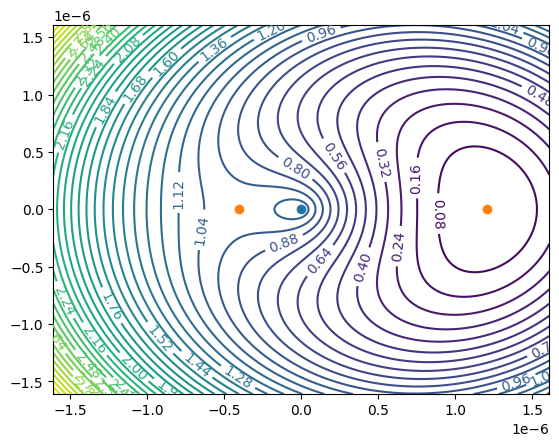

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plot_contour(ax, lens_model_list, eta10, eta11, 4*thetaE1, kwargs_lens_list, beta0, beta1, MacroImg_ra, MacroImg_dec,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=False)


[1.20792235e-06 1.20801475e-06] [-8.47327879e-11  4.35150951e-11] Img_pos


<Axes: >

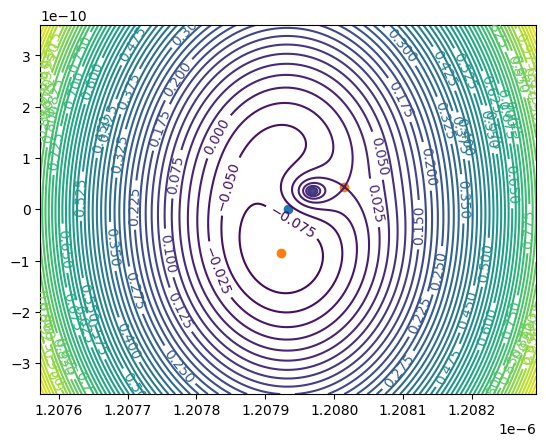

In [21]:
fig1, ax1 = plt.subplots()
plot_contour(ax1, lens_model_list, MacroImg_ra[microtype], MacroImg_dec[microtype], 20*thetaE2, kwargs_lens_list, beta0, beta1, Img_ra, Img_dec,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=True)

In [22]:
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# lens_model_list = ['POINT_MASS']
lens_model_complete = LensModel(lens_model_list=lens_model_list)
lensmodelext = LensModelExtensions(lens_model_complete)
ra_crit_list, dec_crit_list = lensmodelext.critical_curve_tiling(kwargs_lens_list, compute_window=10*thetaE2, start_scale = thetaE2/100, center_x=MacroImg_ra[1], center_y=MacroImg_dec[1])
ra_caustic_list, dec_caustic_list = lens_model_complete.ray_shooting(ra_crit_list, dec_crit_list, kwargs_lens_list)
macro_srcx, macro_srcy = lens_model_complete.ray_shooting(MacroImg_ra, MacroImg_dec, kwargs_lens_list)
lens_srcx, lens_srcy = lens_model_complete.ray_shooting(eta20, eta21, kwargs_lens_list)

In [23]:
micro_srcx, micro_srcy = lens_model_complete.ray_shooting(Img_ra, Img_dec, kwargs_lens_list)


In [24]:
Img_ra, Img_dec

(array([1.20792235e-06, 1.20801475e-06]),
 array([-8.47327879e-11,  4.35150951e-11]))

In [25]:
micro_srcx, micro_srcy

(array([4.02644403e-07, 4.02644403e-07]), array([0., 0.]))

In [26]:
micro_srcx[1:3]

array([4.02644403e-07])

In [27]:
mL=60

In [28]:
# source1 = np.array([micro_srcx[1], micro_srcy[1]])
source1 = np.array([macro_srcx[0], macro_srcy[0]])
# source2 = np.array([micro_srcx[2], micro_srcy[2]])

In [29]:
from lensmodels.trip_d import analytic_fold
fs = np.linspace(10, 2000, 1991)
zL = 0.5
img_1 = analytic_fold(lens_model_list, MacroImg_ra[1], MacroImg_dec[1], source1, kwargs_lens_list, zL, zS, mL, fs)
# img_2 = analytic_fold(lens_model_list, Img_ra[2], Img_dec[2], source2, kwargs_lens_list, zL, zS, mL, fs)

-44281033584.741234 yyy
0.9999999999966477 xx
0.0018538641553377275 1 / Mpc
6.007964560061778e-26


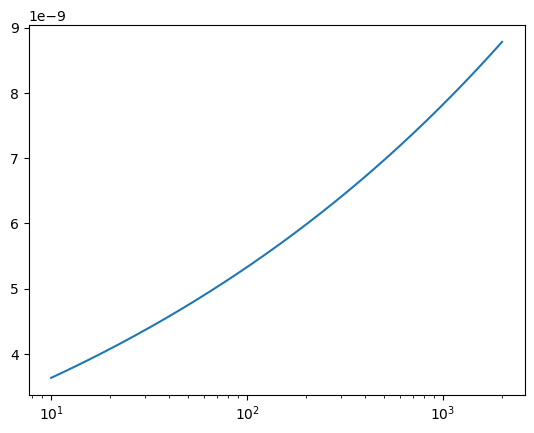

In [30]:
plt.semilogx(fs, np.abs(img_1))
plt.savefig('analy_F.png')

In [108]:
tds = TimeDelay(Img_ra, Img_dec,
               beta0, beta1,
               zL, zS,
               lens_model_list, kwargs_lens_list)
mus = magnifications(Img_ra, Img_dec, lens_model_list, kwargs_lens_list)
ns = getMinMaxSaddle(Img_ra, Img_dec, lens_model_list, kwargs_lens_list, diff = None)

In [109]:
nmus = [mus[0], mus[-1]]
ntds = [tds[0], tds[-1]]
nns = [ns[0], ns[-1]]

In [111]:
from wolensing.utils.utils import compute_geometrical
new_geo = compute_geometrical(fs, nmus, ntds, nns) + img_1 

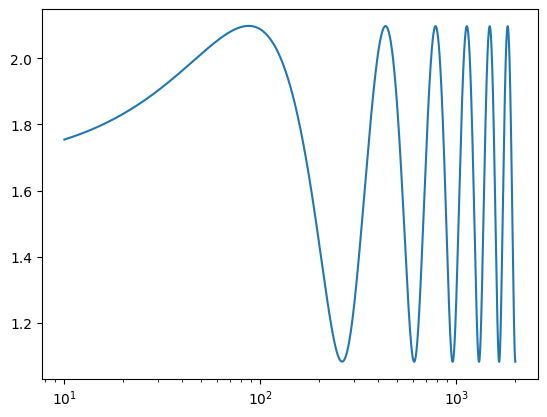

In [112]:
plt.semilogx(fs, np.abs(new_geo))

In [36]:
plt.semilogx(fs, np.angle(new_geo))

NameError: name 'new_geo' is not defined

In [37]:
from utils.lensing import *
from utils.constants import c
frequencies = [10, 100, 500, 1000, 2000]
radii = [c / freq for freq in frequencies]
print(radii)
radii = [3.24e-17 * r  for r in radii]
# print(radii)
angles = distance_to_angle(radii, zL)

[29979245.8, 2997924.58, 599584.916, 299792.458, 149896.229]


In [38]:
angles

<Quantity [7.69779761e-19, 7.69779761e-20, 1.53955952e-20, 7.69779761e-21,
           3.84889881e-21]>

In [39]:
thetaE

8.052888069635299e-07

In [40]:
# theta = np.linspace(0, 2*np.pi, 100)
# circles_x = [macro_srcx+angles[0]*np.cos(the) for the in theta]
# circles_y = [macro_srcy+angles[0]*np.sin(the) for the in theta]

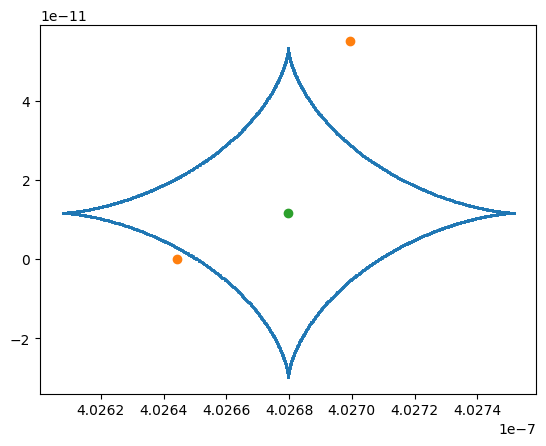

In [85]:
plt.scatter(ra_caustic_list, dec_caustic_list, s=1)
plt.scatter(macro_srcx, macro_srcy)
plt.scatter(lens_srcx, lens_srcy)
# plt.scatter(circles_x, circles_y, s=0.5)

In [42]:
from lensmodels.trip_d import total_triple_d
f_xxx, f_xxy, f_yyx, f_yyy =  total_triple_d(lens_model_list, macro_srcx[0], macro_srcx[0], kwargs_lens_list)


In [43]:
from lensmodels.hessian import Hessian_Td
f_xx, f_yy, f_xy = Hessian_Td(lens_model_list, macro_srcx[0], macro_srcx[0], kwargs_lens_list)

In [44]:
f_yyx

-878078.4824240373

In [45]:
tangent = f_xx * np.array([-f_yyy, f_yyx])
tangent_unit = tangent / (np.sqrt(tangent[0]**2+tangent[1]**2))

In [46]:
tangent_unit[0]

-0.9486832982220452

In [88]:
angle = np.arccos(tangent_unit[0])

In [82]:
angle1 = np.arctan(lens_srcy/lens_srcx)

In [100]:
angle = angle-np.pi/2

In [76]:
macro_vec = macro/np.linalg.norm(macro)

In [101]:
macro = np.array([macro_srcx[0], macro_srcy[0]])
rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
new_macro = np.dot(rotation, macro)

In [63]:
new_macro

array([-3.81982023e-07,  1.27327341e-07])

In [102]:
caustic = np.vstack((ra_caustic_list, dec_caustic_list))
rotated_caustic = np.dot(rotation, caustic)
ncau_x = rotated_caustic[0, :]
ncau_y = rotated_caustic[1, :]

In [103]:
lens_pos = np.array([lens_srcx, lens_srcy])
nlens = np.dot(rotation, lens_pos)

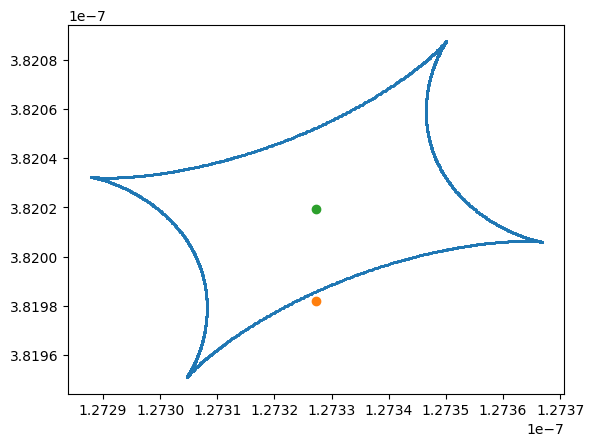

In [104]:
plt.scatter(ncau_x, ncau_y, s=1)
plt.scatter(new_macro[0], new_macro[1])
plt.scatter(nlens[0], nlens[1])

In [95]:

ori_x = nlens[0]
ori_y = nlens[1]
ncau_x -= ori_x
ncau_y -= ori_y
nmac_x = new_macro[0]-ori_x
nmac_y = new_macro[1]-ori_y

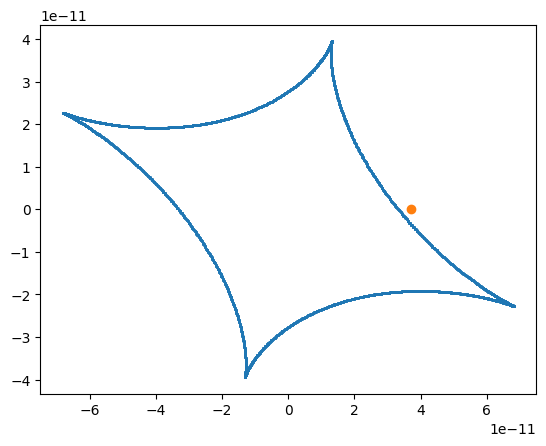

In [96]:
plt.scatter(ncau_x, ncau_y, s=1)
plt.scatter(nmac_x, nmac_y)

In [70]:
nmac_x, nmac_y

(3.719294810591859e-11, 1.3071842046551298e-15)

In [54]:
new_macro[0], new_macro[1]

(-9.060574695996297e-08, -3.923176216007132e-07)

In [ ]:
-9.060574695820915e-08

In [ ]:
Tscale = 4 * (1 + zL) * mtot * M_sun * G / c ** 3


In [26]:
# Define the characteristic WindowSize
mL3 = 10
thetaE3 = param_processing(zL, zS, mL3)

In [27]:
import time

start


Integrating...: 100%|██████████| 441/441 [02:18<00:00,  3.18it/s]


[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.38379680e-22
 2.41025166e-22 2.40095671e-22]
29909 1 shi
total time 10.99999


<Figure size 640x480 with 0 Axes>

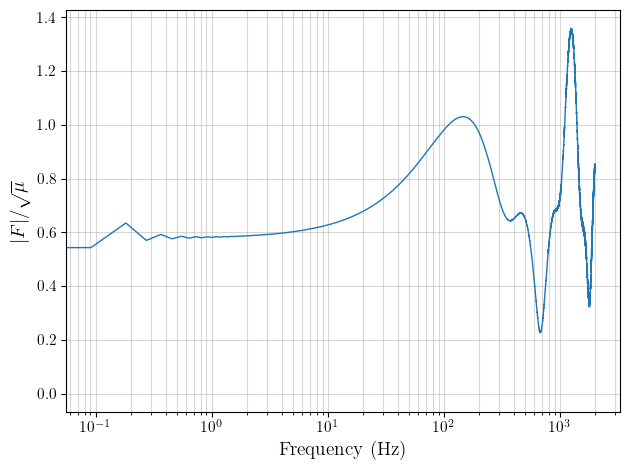

<Axes: xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [77]:
kwargs_macro = {'source_pos_x': beta0,
                'source_pos_y': beta1,
                'theta_E': thetaE,
                'mu': np.abs(Mus[microtype]),
               }

kwargs_integrator = {'PixelNum': int(40000),
                     'PixelBlockMax': 2000,
                     'WindowSize': 2.*210*thetaE3,
                     'WindowCenterX': MacroImg_ra[microtype],
                     'WindowCenterY': MacroImg_dec[microtype],
                     'T0': T0,
                     'TimeStep': 1e-5/Tscale, 
                     'TimeMax': T0 + .7/Tscale,
                     'TimeMin': T0 - .3/Tscale,
                     'TimeLength': 1./Tscale,
                     'TExtend': 10/Tscale,
                     'LastImageT': .02/Tscale,
                     'Tbuffer': .1/Tscale,
                     'Tscale': Tscale}


amplification = af.amplification_factor(lens_model_list=lens_model_list, kwargs_lens=kwargs_lens_list, kwargs_macro=kwargs_macro, **kwargs_integrator)
ts, Ft = amplification.integrator(gpu=False)
ws, Fws = amplification.fourier()
amplification.plot_freq()

<Figure size 640x480 with 0 Axes>

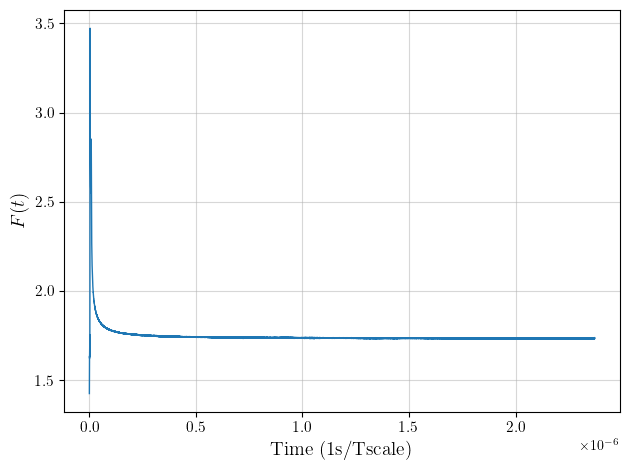

<Axes: xlabel='Time (1s/Tscale)', ylabel='$F(t)$'>

In [78]:
amplification.plot_time()

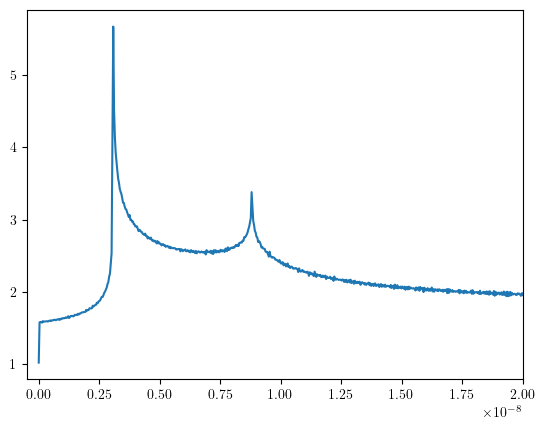

In [82]:
plt.xlim(-.5e-9, 2e-8)
plt.plot(ts, Ft)

<Figure size 640x480 with 0 Axes>

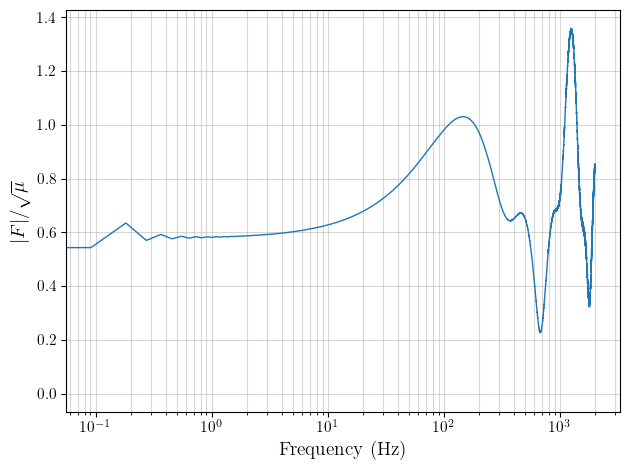

<Axes: xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [80]:
amplification.plot_freq(smooth=False)

<Figure size 640x480 with 0 Axes>

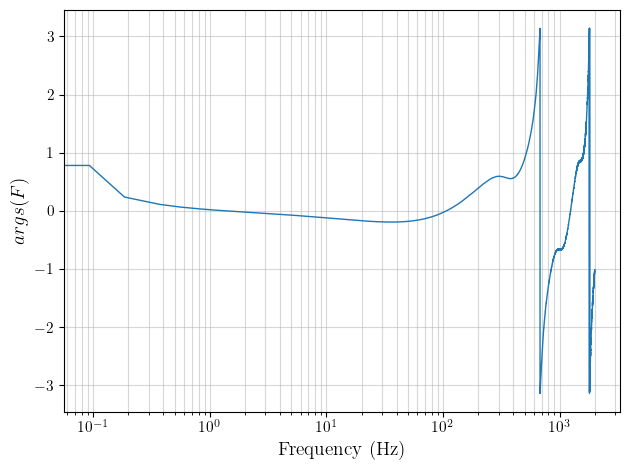

<Axes: xlabel='Frequency (Hz)', ylabel='$args(F)$'>

In [31]:
amplification.plot_freq(pha=True, smooth=False)

# Geometrical optics
To get the geometrical optics around type 1 image, we need the magnifications, time delay and the image positions of the microimages

In [33]:
tds = TimeDelay(Img_ra, Img_dec,
               beta0, beta1,
               zL, zS,
               lens_model_list, kwargs_lens_list)
mus = magnifications(Img_ra, Img_dec, lens_model_list, kwargs_lens_list)
ns = getMinMaxSaddle(Img_ra, Img_dec, lens_model_list, kwargs_lens_list, diff = None)

In [34]:
mus

array([ 2.48805369,  8.78755388, -7.98181437, -0.2937932 ])

In [35]:
tds

array([0.        , 0.00090345, 0.00090653, 0.00260427])

In [76]:
Img_ra, Img_dec

(array([1.20792310e-06, 1.20790334e-06, 1.20789428e-06, 1.20801211e-06]),
 array([-8.78499200e-11,  9.58707571e-11,  7.67386794e-11,  3.87355213e-11]))

In [74]:
from wolensing.utils.utils import Morse_indices
ns = Morse_indices(lens_model_list, Img_ra, Img_dec, kwargs_lens_list)

In [75]:
ns

array([0. , 0. , 0.5, 0.5])

In [33]:
Img_dec

array([-8.78499200e-11,  9.58707571e-11,  7.67386794e-11,  3.87355213e-11])

In [34]:
geofs, geoFws = amplification.geometrical_optics(mus, tds, Img_ra, Img_dec, upper_lim=2000)

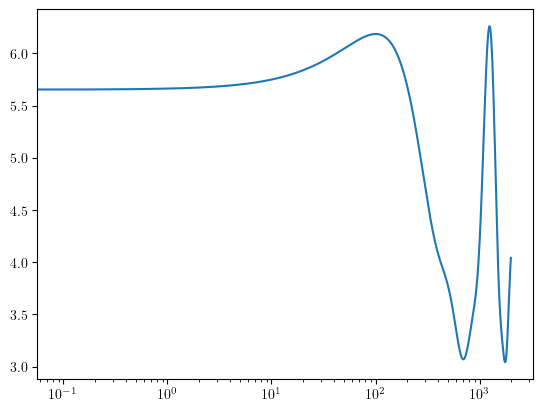

In [35]:
plt.semilogx(geofs, np.abs(geoFws))

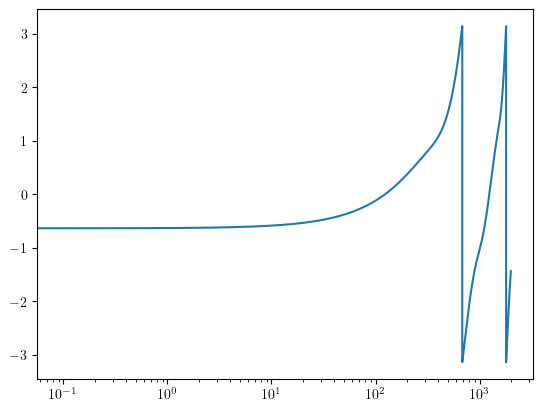

In [36]:
plt.semilogx(geofs, np.angle(geoFws))

# Full amplification factor concatenated with geometrical optics
Given the computaional cost of the diffraction integral, we concatenate the result of wave optics at low frequency and geometrical optics at high frequency to obtain a full amplification factor with default upper bound of 3000Hz.

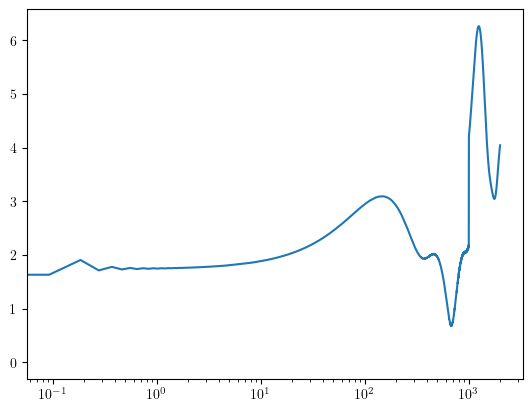

In [37]:
fullfs, fullFws = amplification.concatenate()
plt.semilogx(fullfs, np.abs(fullFws))

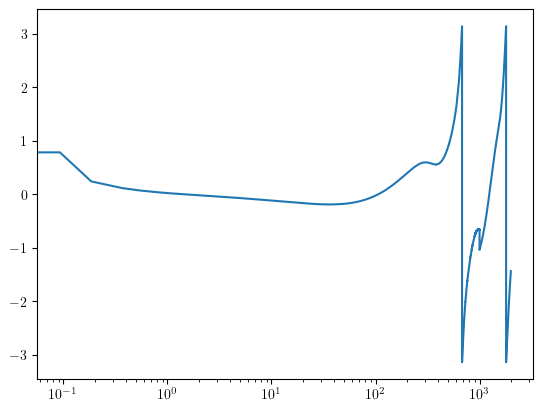

In [38]:
plt.semilogx(fullfs, np.angle(fullFws))

In [39]:
fac = np.sqrt(np.abs(Mus[microtype]))

In [40]:
plt.clf()
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

<Figure size 640x480 with 0 Axes>

In [41]:
from bisect import bisect_left
low_index = bisect_left(geofs, 1)
geofs = geofs[low_index:]
geoFws = geoFws[low_index:]
ws = ws[low_index:]
Fws = Fws[low_index:]

(1, 2000)

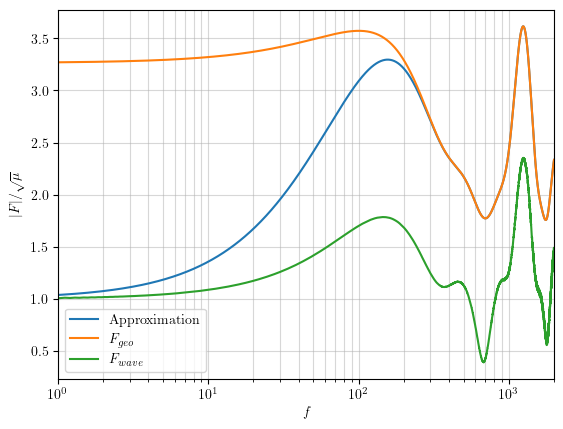

In [42]:
ww = geofs
plt.semilogx(geofs, (fac*np.exp(-ww*np.pi/188) + (1-np.exp(-ww*np.pi/188))*np.abs(geoFws))/fac, label='Approximation')
plt.semilogx(geofs, np.abs(geoFws)/fac,label=r'$F_{geo}$')
plt.semilogx(ws, np.abs(Fws)/fac, label=r'$F_{wave}$')
plt.ylabel(r'$|F|/\sqrt{\mu}$')
plt.xlabel(r'$f$')
plt.grid(which='both', alpha=0.5)
plt.legend()
plt.xlim(1, 2000)
# plt.savefig('./approx.png',bbox_inches='tight', dpi=300)

(1, 2000)

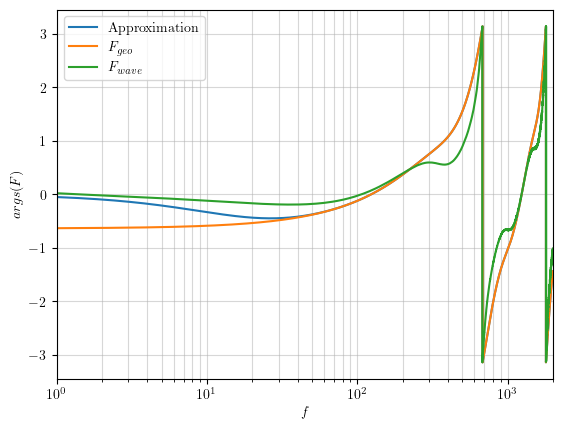

In [43]:
plt.semilogx(geofs, (1-np.exp(-ww*np.pi/37.5))*np.angle(geoFws), label='Approximation')
plt.semilogx(geofs, np.angle(geoFws),label=r'$F_{geo}$')
plt.semilogx(ws, np.angle(Fws), label=r'$F_{wave}$')
plt.ylabel(r'$args(F)$')
plt.xlabel(r'$f$')
plt.grid(which='both', alpha=0.5)
plt.legend()
plt.xlim(1, 2000)
# plt.savefig('./approx_ang.png',bbox_inches='tight', dpi=300)

In [44]:
Abs = (fac*np.exp(-ww*np.pi/1000) + (1-np.exp(-ww*np.pi/1000))*np.abs(geoFws))/fac
Pha = (1-np.exp(-ww*np.pi/1000))*np.angle(geoFws)
complete_approx = Abs * np.exp(1j * Pha)

<Figure size 640x480 with 0 Axes>

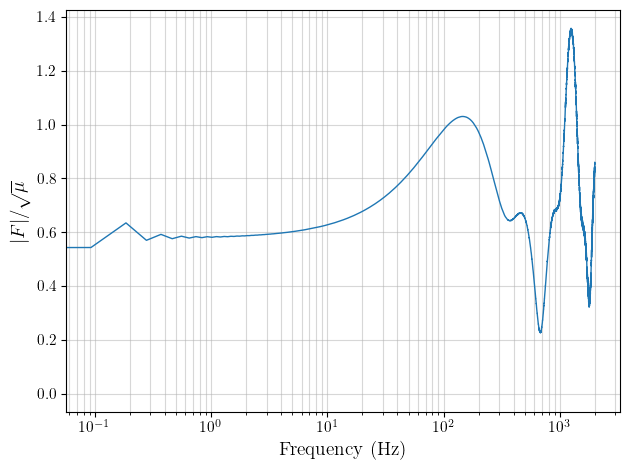

<Axes: xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [45]:
amplification.plot_freq()

<Figure size 640x480 with 0 Axes>

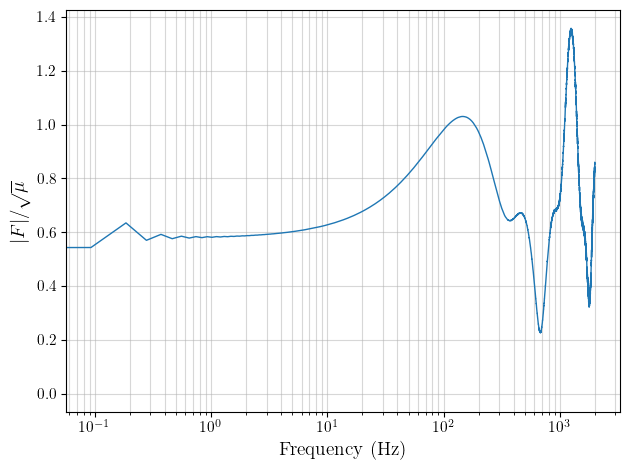

<Axes: xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [46]:
amplification.plot_freq(smooth=False)

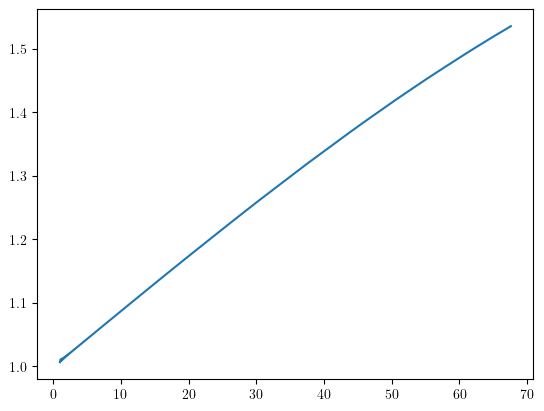

In [47]:
plt.plot(ws[:720], np.abs(Fws[:720])/np.sqrt(3))

In [48]:
from bisect import bisect_left
i = bisect_left(ws, 60)


In [49]:
i

637

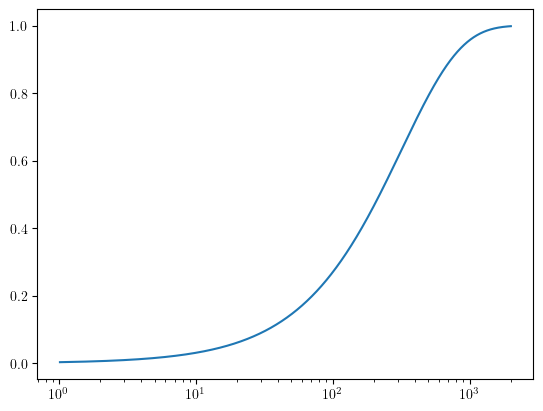

In [50]:
plt.semilogx(ww,(1-np.exp(-ww*np.pi/1000)))

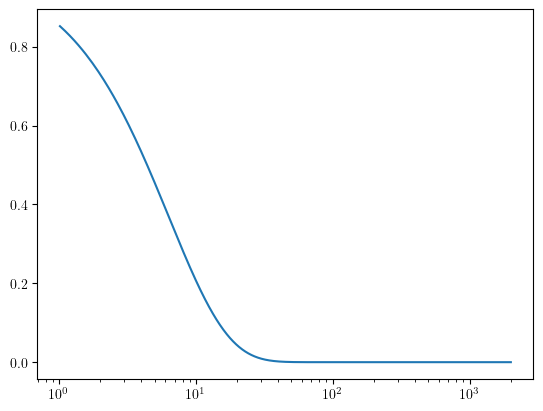

In [51]:
plt.semilogx(ww, np.exp(-ww*np.pi/20))

In [52]:
import pycbc.psd as psd
from pycbc.filter.matchedfilter import overlap, match

hp, hc = get_fd_waveform(approximant = 'IMRPhenomXPHM',
                         mass1 = 30,
                         mass2 = 30,
                         delta_f = .04,
                         f_lower = 10,
                         f_final = 2000)
dfnoise = 0.04
noiselen = int(2001/dfnoise)+1
noise2 = psd.analytical.aLIGOaLIGODesignSensitivityT1800044(noiselen, dfnoise, 1)
noisef = np.linspace(1, 1 + dfnoise*(noiselen-1), num = noiselen)

/home/manchun.yeung/.conda/envs/wolensing/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


NameError: name 'get_fd_waveform' is not defined

In [ ]:
np.savetxt('gf.txt', geofs)
np.savetxt('complete.txt', complete_approx)
np.savetxt('ws.txt', ws)
np.savetxt('Fws.txt', Fws)

In [ ]:
np.savetxt('gwoF.txt', geoFws)

In [ ]:
mus, tds, ns

In [ ]:
Img_ra

In [ ]:
from wolensing.utils.utils import *
Morse_indices(amplification._lens_model_list, Img_ra, Img_dec, amplification._kwargs_lens)

In [ ]:
plt.plot(geofs, -0.000435*geofs + np.pi - 23/geofs)